In [129]:
print('hi')


hi


In [130]:
import pandas as pd
df = pd.read_csv('studentData.csv')

In [131]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [132]:
df.shape

(100, 3)

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [134]:
df.describe()

,iq
count,100.000000
mean,123.580000
std,39.944198
min,37.000000
25%,101.500000
50%,127.500000
75%,149.000000
max,233.000000


In [135]:
#df.head()

In [136]:
#!pip install matplotlib
# import sys
# !{sys.executable} -m pip install matplotlib

In [137]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'iq')

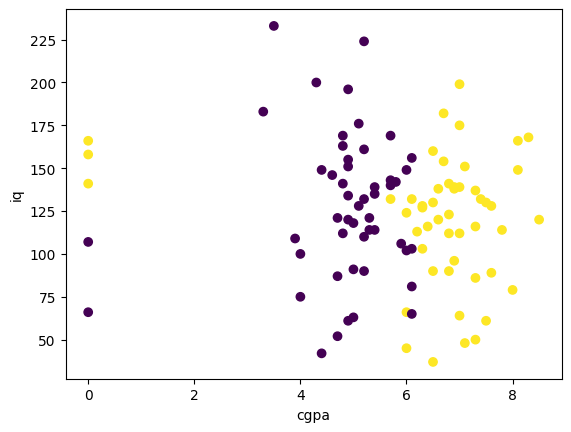

In [138]:
# plt.scatter([1,2,3,4],[2,3,4,5])

#use to covert '8,6' to 8.6 type of float
df["cgpa"] = df["cgpa"].str.replace(",", ".", regex=False).astype(float)

df['cgpa'].dtype
df["cgpa"].unique()
df["cgpa"].head(10)

df['placement'] = df['placement'].map({'No': 0, 'Yes': 1})

df['placement'].dtype #float
df['placement'] = df['placement'].astype(int)
df['placement'].dtype

#remove nan with 0
df['cgpa'] = df['cgpa'].fillna(0)
# df.info()

# or replacing 0 with mean value of cgpa
# mean_cgpa = df.loc[df['cgpa'] != 0, 'cgpa'].mean() # 5.9
# df['cgpa'] = df['cgpa'].replace(0, mean_cgpa).fillna(mean_cgpa)
# df.info()
# df.tail(10)


#yellow color shows placed students data
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
plt.xlabel('cgpa')
plt.ylabel('iq')


In [139]:
#independ variable (input data)
x = df.iloc[:,:2]

#output data
y = df.iloc[:,2:]
print(x)
print(y)


    cgpa     iq
0    6.8  123.0
1    5.9  106.0
2    5.3  121.0
3    7.4  132.0
4    5.8  142.0
..   ...    ...
95   4.3  200.0
96   4.4   42.0
97   6.7  182.0
98   6.3  103.0
99   6.2  113.0

[100 rows x 2 columns]
    placement
0           1
1           0
2           0
3           1
4           0
..        ...
95          0
96          0
97          1
98          1
99          1

[100 rows x 1 columns]


In [140]:
# import sys
# !{sys.executable} -m pip install scikit-learn

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.1)

In [141]:
x_train

,cgpa,iq
27,6.0,124.0
79,6.5,90.0
13,6.4,116.0
4,5.8,142.0
16,5.2,224.0
...,...,...
6,5.7,143.0
76,4.9,155.0
42,7.6,89.0
74,6.7,154.0


In [142]:
x_test

,cgpa,iq
48,6.6,138.0
65,8.1,166.0
29,7.0,112.0
51,4.8,141.0
45,6.0,66.0
89,4.9,151.0
61,7.3,137.0
18,4.0,100.0
78,6.1,81.0
23,4.7,87.0


In [143]:
y_train = y_train.squeeze()
y_train

27    1
79    1
13    1
4     0
16    0
     ..
6     0
76    0
42    1
74    1
63    1
Name: placement, Length: 90, dtype: int64

In [144]:
y_test

,placement
48,1
65,1
29,1
51,0
45,1
89,0
61,1
18,0
78,0
23,0


In [145]:
#scale the train test values
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [146]:
x_train = scaler.fit_transform(x_train)

In [147]:
x_train

array([[ 0.1928804 , -0.00521438],
       [ 0.47652805, -0.84500365],
       [ 0.41979852, -0.20281185],
       [ 0.07942134,  0.43937994],
       [-0.26095584,  2.46475406],
       [-0.31768537,  1.27916921],
       [-0.71479208,  0.61227773],
       [ 1.61111865, -0.10401312],
       [-0.99843972, -0.37570964],
       [ 0.81690523,  0.6616771 ],
       [-0.3744149 , -0.15341248],
       [ 0.1928804 , -0.54860743],
       [ 0.93036429, -0.94380238],
       [ 0.47652805,  0.88397426],
       [-0.20422631, -0.25221122],
       [ 1.10055288,  0.09358436],
       [ 1.38420053,  0.61227773],
       [ 0.24960993,  0.78517552],
       [ 0.7601757 , -1.48719544],
       [-0.14749678,  0.36528089],
       [-0.54460349, -1.78359165],
       [-1.22535784,  2.68705122],
       [-3.21089139, -0.42510901],
       [ 0.70344617,  0.36528089],
       [ 0.1928804 ,  0.61227773],
       [-0.43114443,  1.7731629 ],
       [ 0.70344617, -0.69680554],
       [ 0.36306899, -0.52390775],
       [-0.26095584,

In [148]:
x_test = scaler.transform(x_test)
x_test

array([[ 0.53325758,  0.3405812 ],
       [ 1.38420053,  1.03217237],
       [ 0.7601757 , -0.30161059],
       [-0.48787396,  0.41468026],
       [ 0.1928804 , -1.43779607],
       [-0.43114443,  0.6616771 ],
       [ 0.93036429,  0.31588152],
       [-0.94171019, -0.5980068 ],
       [ 0.24960993, -1.06730081],
       [-0.54460349, -0.9191027 ]])

In [149]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [150]:
#model training
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [151]:
y_pred = clf.predict(x_test)  # or X_test
print(y_pred[:10])             # first 10 predictions


[1 1 1 0 1 0 1 0 1 0]


In [152]:
y_test

,placement
48,1
65,1
29,1
51,0
45,1
89,0
61,1
18,0
78,0
23,0


In [153]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred[:10],y_test)

0.9

In [154]:
# import sys
# !{sys.executable} -m pip install mlxtend
import numpy as np

In [155]:
from mlxtend.plotting import plot_decision_regions

In [156]:
y_train = np.array(y_train)

<Axes: >

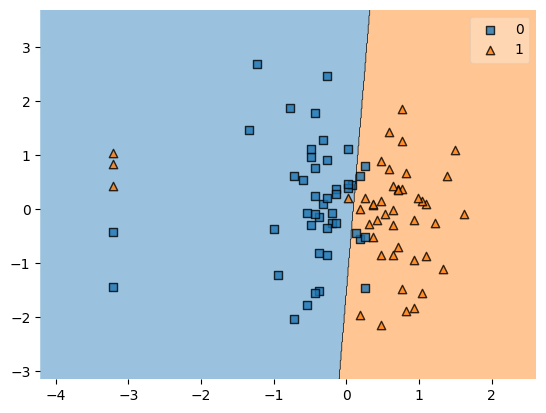

In [157]:
plot_decision_regions(x_train,y_train,clf=clf)

In [158]:
import pickle

In [159]:
pickle.dump(clf,open('new_model.pkl','wb'))